# Import libraries

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm

import seaborn as sns

import json

from sklearn.feature_selection import mutual_info_classif

from collections import defaultdict

from tqdm import tqdm

In [2]:
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)

In [3]:
path_to_save = './../results/03d_features_analysis'

# Loading data

In [4]:
path_to_ftir_data_3800_2500 = './../data/processed_data/dataset_3800_2500_engineered.csv'
path_to_ftir_data_1900_800 = './../data/processed_data/dataset_1900_800_engineered.csv'

path_to_features_description_3800_2500 = './../data/processed_data/features_description_3800_2500.json'
path_to_features_description_1900_800 = './../data/processed_data/features_description_1900_800.json'

## FTIR-features (*long-list*)

In [5]:
dataset_3800_2500 = pd.read_csv(path_to_ftir_data_3800_2500, sep=';', index_col=0)

print(dataset_3800_2500.shape)
dataset_3800_2500.head(3)

(75, 49)


,$I_{2928}$,$I_{3355}$,$I_{3725}$,$\overline{I}_{3800\text{–}2500}$,"$\Sigma I_{p,\ 3800\text{–}2500}$",$\overline{I}_{2928 \pm 50}$,$\overline{I}_{3355 \pm 50}$,$\overline{I}_{3725 \pm 50}$,$\log I_{2928}$,$(I_{2928})^{-1}$,$\log I_{3355}$,$(I_{3355})^{-1}$,$\log I_{3725}$,$(I_{3725})^{-1}$,$\log \overline{I}_{3800\text{–}2500}$,$(\overline{I}_{3800\text{–}2500})^{-1}$,"$\log \Sigma I_{p,\ 3800\text{–}2500}$","$(\Sigma I_{p,\ 3800\text{–}2500})^{-1}$",$\log \overline{I}_{2928 \pm 50}$,$(\overline{I}_{2928 \pm 50})^{-1}$,$\log \overline{I}_{3355 \pm 50}$,$(\overline{I}_{3355 \pm 50})^{-1}$,$\log \overline{I}_{3725 \pm 50}$,$(\overline{I}_{3725 \pm 50})^{-1}$,$\frac{I_{2928}}{I_{3355}}$,$\frac{I_{2928}}{I_{3725}}$,$\frac{I_{2928}}{\overline{I}_{3800\text{–}2500}}$,"$\frac{I_{2928}}{\Sigma I_{p,\ 3800\text{–}2500}}$",$\frac{I_{2928}}{\overline{I}_{3355 \pm 50}}$,$\frac{I_{2928}}{\overline{I}_{3725 \pm 50}}$,$\frac{I_{3355}}{I_{3725}}$,$\frac{I_{3355}}{\overline{I}_{3800\text{–}2500}}$,"$\frac{I_{3355}}{\Sigma I_{p,\ 3800\text{–}2500}}$",$\frac{I_{3355}}{\overline{I}_{2928 \pm 50}}$,$\frac{I_{3355}}{\overline{I}_{3725 \pm 50}}$,$\frac{I_{3725}}{\overline{I}_{3800\text{–}2500}}$,"$\frac{I_{3725}}{\Sigma I_{p,\ 3800\text{–}2500}}$",$\frac{I_{3725}}{\overline{I}_{2928 \pm 50}}$,$\frac{I_{3725}}{\overline{I}_{3355 \pm 50}}$,$\frac{\overline{I}_{3800\text{–}2500}}{\overline{I}_{2928 \pm 50}}$,$\frac{\overline{I}_{3800\text{–}2500}}{\overline{I}_{3355 \pm 50}}$,$\frac{\overline{I}_{3800\text{–}2500}}{\overline{I}_{3725 \pm 50}}$,$\frac{\overline{I}_{2928 \pm 50}}{\overline{I}_{3355 \pm 50}}$,$\frac{\overline{I}_{2928 \pm 50}}{\overline{I}_{3725 \pm 50}}$,$\frac{\overline{I}_{3355 \pm 50}}{\overline{I}_{3725 \pm 50}}$,Split,Fraction_hue,Fraction_grouped_hue,Class
division_1_size_bulk,0.491720,1.0,0.088957,0.526201,1.580676,0.494443,0.982242,0.075964,-0.709847,2.033679,0.0,1.0,-2.419606,11.241429,-0.642072,1.900414,0.457853,0.632641,-0.704324,2.022478,-0.017917,1.018079,-2.577498,13.164155,0.491720,5.527631,0.934471,0.311082,0.500609,6.473072,11.241429,1.900414,0.632641,2.022478,13.164155,0.169054,0.056278,0.179913,0.090565,1.064230,0.535714,6.926993,0.503382,6.508923,12.930390,Train,$> 0$,$d > 5$,2
division_1_size_5,0.406937,1.0,0.028525,0.477909,1.435462,0.396989,0.982472,0.035765,-0.899098,2.457385,0.0,1.0,-3.556968,35.056730,-0.738335,2.092448,0.361487,0.696640,-0.923846,2.518960,-0.017684,1.017841,-3.330798,27.960634,0.406937,14.265868,0.851494,0.283488,0.414197,11.378206,35.056730,2.092448,0.696640,2.518960,27.960634,0.059687,0.019872,0.071854,0.029034,1.203834,0.486436,13.362643,0.404072,11.100072,27.470532,Train,$< 5$,$2 < d \leq 5$,1
division_1_size_3,0.618445,1.0,0.079233,0.535789,1.697678,0.581733,0.981591,0.067710,-0.480547,1.616959,0.0,1.0,-2.535360,12.620970,-0.624015,1.866407,0.529262,0.589040,-0.541743,1.719000,-0.018581,1.018755,-2.692524,14.768908,0.618445,7.805375,1.154270,0.364289,0.630044,9.133756,12.620970,1.866407,0.589040,1.719000,14.768908,0.147881,0.046672,0.136202,0.080719,0.921021,0.545837,7.913018,0.592644,8.591567,14.497024,Train,$< 3$,$2 < d \leq 5$,1


In [6]:
dataset_1900_800 = pd.read_csv(path_to_ftir_data_1900_800, sep=';', index_col=0)

print(dataset_1900_800.shape)
dataset_1900_800.head(3)

(75, 324)


,$I_{873}$,$I_{1105}$,$I_{1241}$,$I_{1394}$,$I_{1615}$,$I_{1726}$,$\overline{I}_{1900\text{–}800}$,"$\Sigma I_{p,\ 1900\text{–}800}$",$\overline{I}_{1900\text{–}1500}$,"$\Sigma I_{p,\ 1900\text{–}1500}$",$\overline{I}_{1500\text{–}1300}$,"$\Sigma I_{p,\ 1500\text{–}1300}$",$\overline{I}_{1300\text{–}800}$,"$\Sigma I_{p,\ 1300\text{–}800}$",$\overline{I}_{873 \pm 25}$,$\overline{I}_{873 \pm 50}$,$\overline{I}_{1105 \pm 25}$,$\overline{I}_{1105 \pm 50}$,$\overline{I}_{1241 \pm 25}$,$\overline{I}_{1241 \pm 50}$,$\overline{I}_{1394 \pm 25}$,$\overline{I}_{1394 \pm 50}$,$\overline{I}_{1615 \pm 25}$,$\overline{I}_{1615 \pm 50}$,$\overline{I}_{1726 \pm 25}$,...,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1394 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1394 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1615 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1615 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1615 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1615 \pm 50}}{\overline{I}_{1726 \pm 50}}$,Split,Fraction_hue,Fraction_grouped_hue,Class
division_1_size_bulk,0.048208,0.681294,0.455066,0.760582,1.0,0.421995,0.424162,3.367146,0.426619,1.421995,0.571735,0.760582,0.363338,1.184569,0.047543,0.047916,0.628121,0.615327,0.447733,0.442677,0.738860,0.689531,0.944739,0.845640,0.415802,...,0.529461,1.076795,1.083008,0.599136,0.641997,0.468571,0.523482,1.064635,1.070778,0.782078,0.873729,1.776952,1.787205,0.729864,0.815396,1.658317,1.667886,2.272090,2.285200,2.033758,2.045493,Train,$> 0$,$d > 5$,2
division_1_size_5,0.091875,0.606138,0.427988,0.687458,1.0,0.383362,0.378730,3.196821,0.378004,1.383362,0.502368,0.687458,0.329999,1.126001,0.093349,0.096086,0.593910,0.562713,0.424918,0.421892,0.667947,0.619315,0.937481,0.831352,0.376555,...,0.511117,1.128435,1.144119,0.631625,0.681223,0.450027,0.507477,1.120398,1.135971,0.712490,0.803446,1.773835,1.798490,0.660616,0.744949,1.644686,1.667546,2.489626,2.524230,2.207783,2.238470,Train,$< 5$,$2 < d \leq 5$,1
division_1_size_3,0.110321,0.836176,0.400950,0.696553,1.0,0.366658,0.436266,3.410658,0.429362,1.366658,0.523513,0.696553,0.406988,1.347446,0.113396,0.114054,0.816077,0.774107,0.401435,0.409080,0.678774,0.631706,0.957114,0.877520,0.366774,...,0.457465,1.094502,1.068776,0.602674,0.647579,0.427409,0.466177,1.115345,1.089129,0.709188,0.773515,1.850661,1.807162,0.660011,0.719876,1.722330,1.681847,2.609548,2.548211,2.392536,2.336300,Train,$< 3$,$2 < d \leq 5$,1


## Features description

In [7]:
with open(path_to_features_description_3800_2500, 'r', encoding='utf-8') as f:
    features_description_3800_2500 = json.load(f)

In [8]:
with open(path_to_features_description_1900_800, 'r', encoding='utf-8') as f:
    features_description_1900_800 = json.load(f)

# Data wrangling

## Merging dataframes and dicts

In [9]:
data = pd.merge(
    left=dataset_3800_2500.loc[:, ~dataset_3800_2500.columns.isin(['Split', 'Fraction_hue', 'Fraction_grouped_hue', 'Class'])],
    right=dataset_1900_800,
    left_index=True,
    right_index=True
)

print(data.shape)
data.head(3)

(75, 369)


,$I_{2928}$,$I_{3355}$,$I_{3725}$,$\overline{I}_{3800\text{–}2500}$,"$\Sigma I_{p,\ 3800\text{–}2500}$",$\overline{I}_{2928 \pm 50}$,$\overline{I}_{3355 \pm 50}$,$\overline{I}_{3725 \pm 50}$,$\log I_{2928}$,$(I_{2928})^{-1}$,$\log I_{3355}$,$(I_{3355})^{-1}$,$\log I_{3725}$,$(I_{3725})^{-1}$,$\log \overline{I}_{3800\text{–}2500}$,$(\overline{I}_{3800\text{–}2500})^{-1}$,"$\log \Sigma I_{p,\ 3800\text{–}2500}$","$(\Sigma I_{p,\ 3800\text{–}2500})^{-1}$",$\log \overline{I}_{2928 \pm 50}$,$(\overline{I}_{2928 \pm 50})^{-1}$,$\log \overline{I}_{3355 \pm 50}$,$(\overline{I}_{3355 \pm 50})^{-1}$,$\log \overline{I}_{3725 \pm 50}$,$(\overline{I}_{3725 \pm 50})^{-1}$,$\frac{I_{2928}}{I_{3355}}$,...,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1394 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1394 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1615 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1615 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1615 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1615 \pm 50}}{\overline{I}_{1726 \pm 50}}$,Split,Fraction_hue,Fraction_grouped_hue,Class
division_1_size_bulk,0.491720,1.0,0.088957,0.526201,1.580676,0.494443,0.982242,0.075964,-0.709847,2.033679,0.0,1.0,-2.419606,11.241429,-0.642072,1.900414,0.457853,0.632641,-0.704324,2.022478,-0.017917,1.018079,-2.577498,13.164155,0.491720,...,0.529461,1.076795,1.083008,0.599136,0.641997,0.468571,0.523482,1.064635,1.070778,0.782078,0.873729,1.776952,1.787205,0.729864,0.815396,1.658317,1.667886,2.272090,2.285200,2.033758,2.045493,Train,$> 0$,$d > 5$,2
division_1_size_5,0.406937,1.0,0.028525,0.477909,1.435462,0.396989,0.982472,0.035765,-0.899098,2.457385,0.0,1.0,-3.556968,35.056730,-0.738335,2.092448,0.361487,0.696640,-0.923846,2.518960,-0.017684,1.017841,-3.330798,27.960634,0.406937,...,0.511117,1.128435,1.144119,0.631625,0.681223,0.450027,0.507477,1.120398,1.135971,0.712490,0.803446,1.773835,1.798490,0.660616,0.744949,1.644686,1.667546,2.489626,2.524230,2.207783,2.238470,Train,$< 5$,$2 < d \leq 5$,1
division_1_size_3,0.618445,1.0,0.079233,0.535789,1.697678,0.581733,0.981591,0.067710,-0.480547,1.616959,0.0,1.0,-2.535360,12.620970,-0.624015,1.866407,0.529262,0.589040,-0.541743,1.719000,-0.018581,1.018755,-2.692524,14.768908,0.618445,...,0.457465,1.094502,1.068776,0.602674,0.647579,0.427409,0.466177,1.115345,1.089129,0.709188,0.773515,1.850661,1.807162,0.660011,0.719876,1.722330,1.681847,2.609548,2.548211,2.392536,2.336300,Train,$< 3$,$2 < d \leq 5$,1


In [10]:
features_description = {}

for d in (features_description_3800_2500, features_description_1900_800):
    for k, v in d.items():
        features_description.setdefault(k, []).extend(v)

print(features_description.keys())

dict_keys(['base_features_peaks_3800_2500', 'base_features_intervals_3800_2500', 'engineered_features_peaks_3800_2500', 'engineered_features_intervals_3800_2500', 'base_features', 'engineered_features', 'base_features_peaks_1900_800', 'base_features_intervals_1900_800', 'engineered_features_peaks_1900_800', 'engineered_features_intervals_1900_800'])


## Base parameters

In [11]:
features_df = data.loc[:, ~data.columns.isin(['Split', 'Fraction_hue', 'Fraction_grouped_hue', 'Class'])]

print(features_df.shape)
features_df.head(3)

(75, 365)


,$I_{2928}$,$I_{3355}$,$I_{3725}$,$\overline{I}_{3800\text{–}2500}$,"$\Sigma I_{p,\ 3800\text{–}2500}$",$\overline{I}_{2928 \pm 50}$,$\overline{I}_{3355 \pm 50}$,$\overline{I}_{3725 \pm 50}$,$\log I_{2928}$,$(I_{2928})^{-1}$,$\log I_{3355}$,$(I_{3355})^{-1}$,$\log I_{3725}$,$(I_{3725})^{-1}$,$\log \overline{I}_{3800\text{–}2500}$,$(\overline{I}_{3800\text{–}2500})^{-1}$,"$\log \Sigma I_{p,\ 3800\text{–}2500}$","$(\Sigma I_{p,\ 3800\text{–}2500})^{-1}$",$\log \overline{I}_{2928 \pm 50}$,$(\overline{I}_{2928 \pm 50})^{-1}$,$\log \overline{I}_{3355 \pm 50}$,$(\overline{I}_{3355 \pm 50})^{-1}$,$\log \overline{I}_{3725 \pm 50}$,$(\overline{I}_{3725 \pm 50})^{-1}$,$\frac{I_{2928}}{I_{3355}}$,...,$\frac{\overline{I}_{1105 \pm 50}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1394 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1394 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1394 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1394 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1241 \pm 50}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1615 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1615 \pm 50}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1394 \pm 50}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1615 \pm 25}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1615 \pm 25}}{\overline{I}_{1726 \pm 50}}$,$\frac{\overline{I}_{1615 \pm 50}}{\overline{I}_{1726 \pm 25}}$,$\frac{\overline{I}_{1615 \pm 50}}{\overline{I}_{1726 \pm 50}}$
division_1_size_bulk,0.491720,1.0,0.088957,0.526201,1.580676,0.494443,0.982242,0.075964,-0.709847,2.033679,0.0,1.0,-2.419606,11.241429,-0.642072,1.900414,0.457853,0.632641,-0.704324,2.022478,-0.017917,1.018079,-2.577498,13.164155,0.491720,...,1.488396,0.605978,0.649330,0.473923,0.529461,1.076795,1.083008,0.599136,0.641997,0.468571,0.523482,1.064635,1.070778,0.782078,0.873729,1.776952,1.787205,0.729864,0.815396,1.658317,1.667886,2.272090,2.285200,2.033758,2.045493
division_1_size_5,0.406937,1.0,0.028525,0.477909,1.435462,0.396989,0.982472,0.035765,-0.899098,2.457385,0.0,1.0,-3.556968,35.056730,-0.738335,2.092448,0.361487,0.696640,-0.923846,2.518960,-0.017684,1.017841,-3.330798,27.960634,0.406937,...,1.515142,0.636156,0.686109,0.453255,0.511117,1.128435,1.144119,0.631625,0.681223,0.450027,0.507477,1.120398,1.135971,0.712490,0.803446,1.773835,1.798490,0.660616,0.744949,1.644686,1.667546,2.489626,2.524230,2.207783,2.238470
division_1_size_3,0.618445,1.0,0.079233,0.535789,1.697678,0.581733,0.981591,0.067710,-0.480547,1.616959,0.0,1.0,-2.535360,12.620970,-0.624015,1.866407,0.529262,0.589040,-0.541743,1.719000,-0.018581,1.018755,-2.692524,14.768908,0.618445,...,2.060975,0.591411,0.635478,0.419422,0.457465,1.094502,1.068776,0.602674,0.647579,0.427409,0.466177,1.115345,1.089129,0.709188,0.773515,1.850661,1.807162,0.660011,0.719876,1.722330,1.681847,2.609548,2.548211,2.392536,2.336300


In [12]:
hue = data['Fraction_grouped_hue'].tolist()
hue_order = sorted(set(hue))

target = data['Class'].tolist()

In [13]:
type_color_dict = {
    '$0< d \leq 2$': '#2166AC',
    '$2 < d \leq 5$': '#67A9CF',
    '$d > 5$': '#B2182B'
}

In [14]:
groups = list(type_color_dict.keys())

In [15]:
feature_types = [
    'base_features_peaks_3800_2500',
    'base_features_intervals_3800_2500',
    'base_features_peaks_1900_800',
    'base_features_intervals_1900_800',
    'engineered_features_peaks_3800_2500',
    'engineered_features_intervals_3800_2500',
    'engineered_features_peaks_1900_800',
    'engineered_features_intervals_1900_800'
]

# Features analysis

In [16]:
sns.set_theme()

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans", "Comic Sans MS"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Mutual information

In [17]:
PLOT_STYLE = {
    'TITLE_FONT_SIZE': 22,
    'TITLE_FONTSTYLE': 'normal',
    'X_LABEL_FONT_SIZE': 20,
    'Y_LABEL_FONT_SIZE': 20,
    'X_TICK_LABEL_FONT_SIZE': 18,
    'Y_TICK_LABEL_FONT_SIZE': 18,
    'X_LABELPAD': 10,
    'Y_LABELPAD': 10,
    'X_NBINS': 6
}

TITLE_MAP = {
    'peaks_3800_2500': 'Peak-based\n3800–2500 cm$^{-1}$',
    'intervals_3800_2500': 'Region-based\n3800–2500 cm$^{-1}$',
    'peaks_1900_800': 'Peak-based\n1900–800 cm$^{-1}$',
    'intervals_1900_800': 'Region-based\n1900–800 cm$^{-1}$'
}

COLORS = {
    'base': 'RoyalBlue',
    'engineered': 'SeaGreen'
}

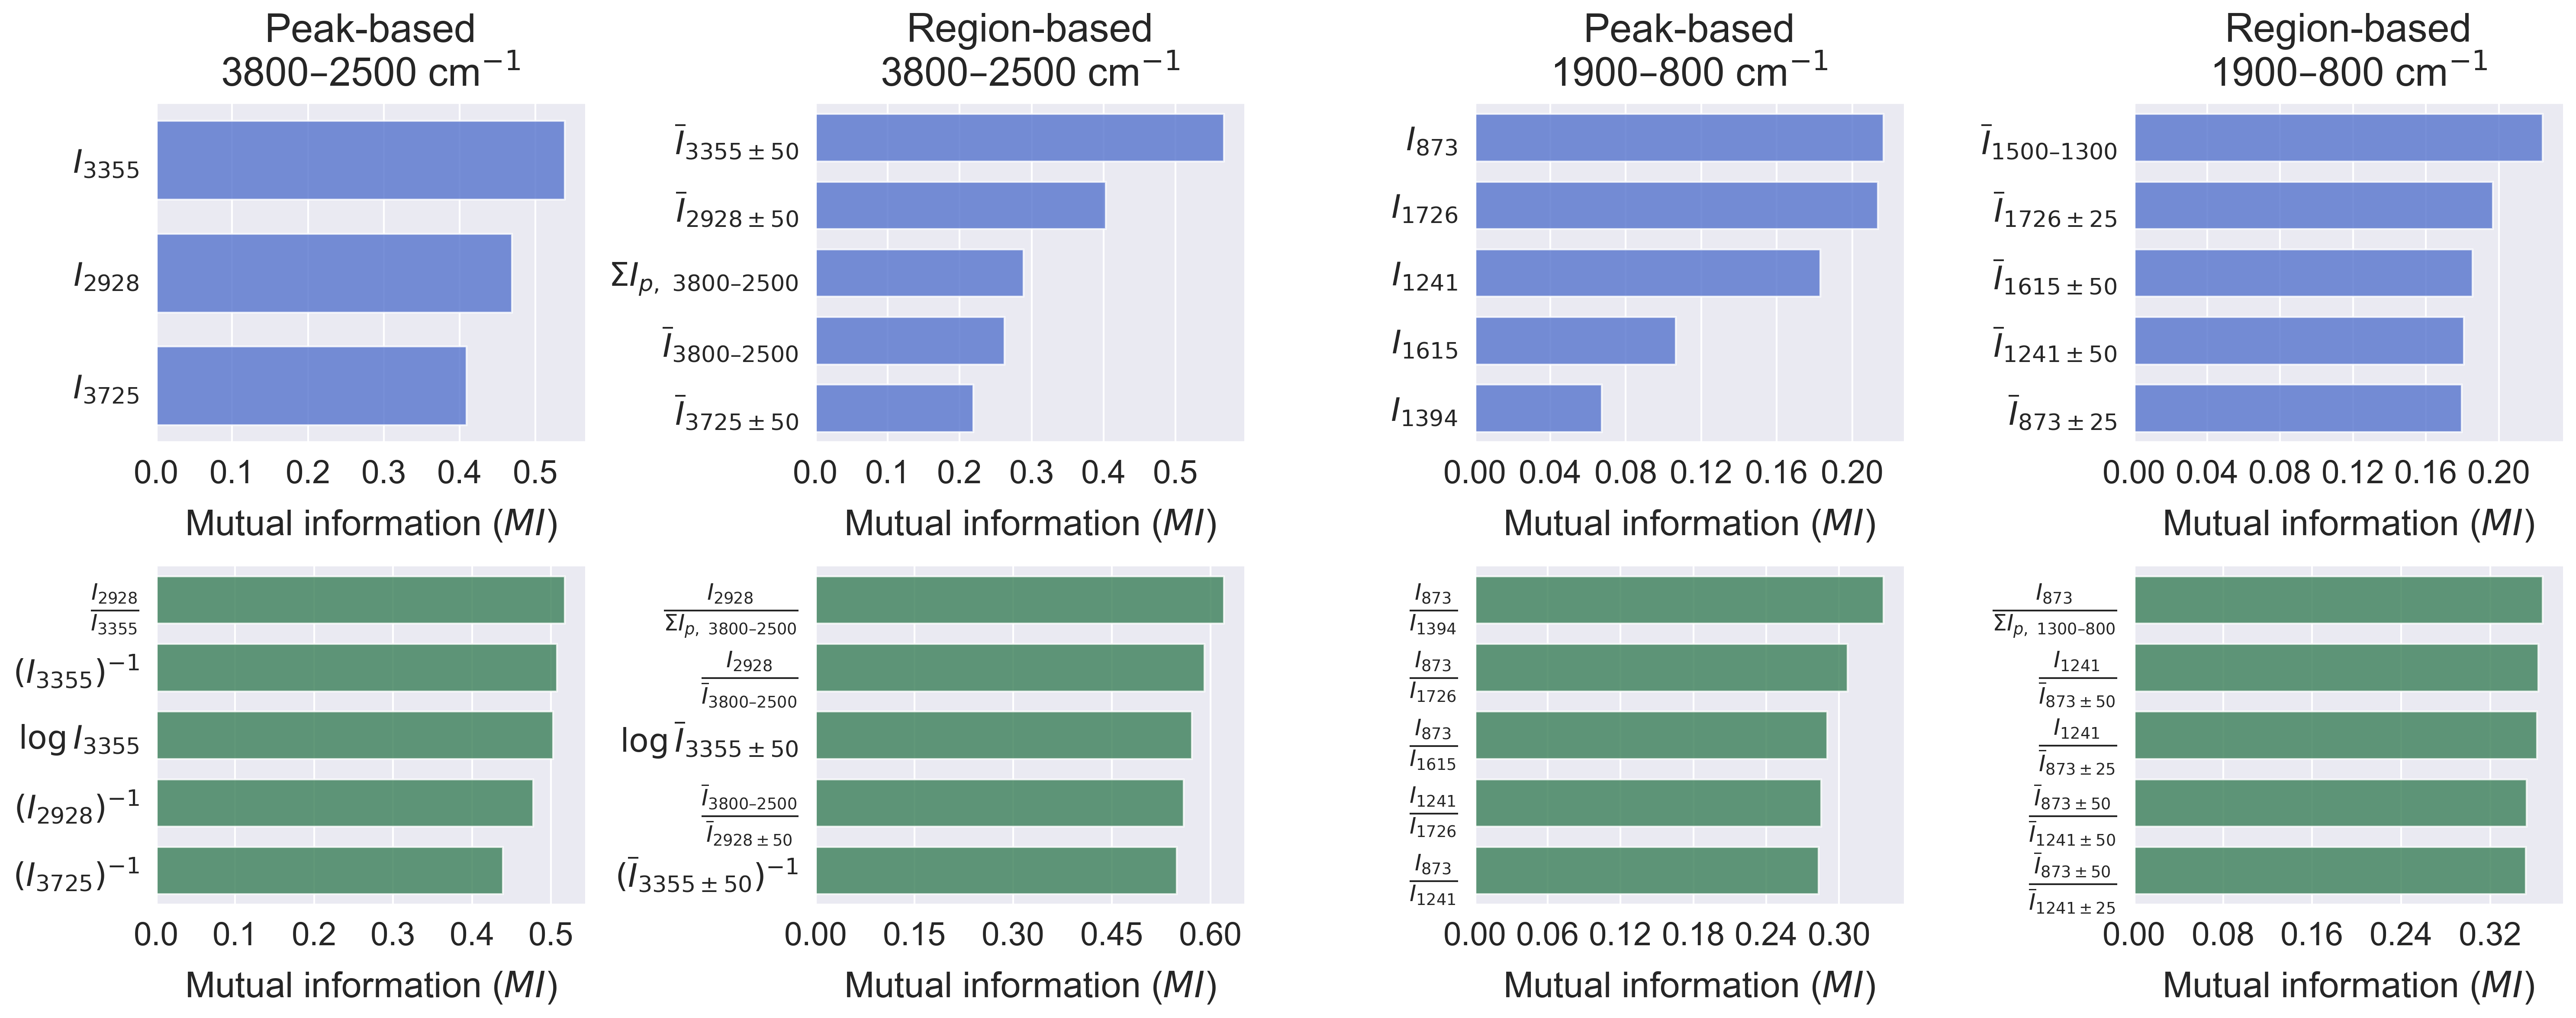

In [18]:
nrows = 2
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4), dpi=300)
axes = axes.flat

for i, feature_type in enumerate(feature_types):
    X_subset = features_df[features_description[feature_type]]
    y_subset = target

    mi = mutual_info_classif(X_subset, y_subset, discrete_features='auto', random_state=42)
    
    result_df = pd.DataFrame({
        'Feature': X_subset.columns,
        'Mutual_Info': mi
    })
    result_df = result_df.sort_values(by='Mutual_Info', ascending=False).head(5)

    ax = axes[i]
    
    kind = 'engineered' if 'engineered' in feature_type else 'base'
    plot_color = COLORS[kind]

    sns.barplot(
        data=result_df,
        x='Mutual_Info',
        y='Feature',
        ax=ax,
        color=plot_color,
        width=0.7,
        alpha=0.8
    )

    if i < 4:
        key = '_'.join(feature_type.split('_')[2:])
        ax.set_title(TITLE_MAP[key], fontsize=PLOT_STYLE['TITLE_FONT_SIZE'], fontstyle=PLOT_STYLE['TITLE_FONTSTYLE'], pad=10)
        ax.set_xlabel('')
    
    ax.set_xlabel('Mutual information ($MI$)', fontsize=PLOT_STYLE['X_LABEL_FONT_SIZE'], labelpad=PLOT_STYLE['X_LABELPAD'])

    ax.set_ylabel('', fontsize=PLOT_STYLE['Y_LABEL_FONT_SIZE'], labelpad=PLOT_STYLE['Y_LABELPAD'])
    
    ax.tick_params(axis='x', labelsize=PLOT_STYLE['X_TICK_LABEL_FONT_SIZE'])
    ax.tick_params(axis='y', labelsize=PLOT_STYLE['Y_TICK_LABEL_FONT_SIZE'])
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=PLOT_STYLE['X_NBINS']))

plt.tight_layout()

plt.savefig(f'{path_to_save}/mutual_info_barplots.png', dpi=1800)
plt.savefig(f'{path_to_save}/mutual_info_barplots.svg')

plt.show()

## Visualization (BoxPlot & ViolinPlot)

In [19]:
base_feature_types = [
    'base_features_peaks_3800_2500',
    'base_features_intervals_3800_2500',
    'base_features_peaks_1900_800',
    'base_features_intervals_1900_800'
]

engineered_feature_types = [
    'engineered_features_peaks_3800_2500',
    'engineered_features_intervals_3800_2500',
    'engineered_features_peaks_1900_800',
    'engineered_features_intervals_1900_800'
]

### Function for sorting by *MS*

In [20]:
def get_ranked_features_by_mutual_info(features_df, target, features_description, feature_types):
    results_lst = []
    
    for feature_type in feature_types:
        X = features_df[features_description[feature_type]]
        mi = mutual_info_classif(X, target, discrete_features='auto', random_state=42)
        
        data = pd.DataFrame({
            'Feature': X.columns,
            'Mutual_Info': mi,
            'Feature_Type': feature_type
        })
        data = data.sort_values('Mutual_Info', ascending=False).reset_index(drop=True)
        
        results_lst.append(data)

    result_data = pd.concat(results_lst, ignore_index=True)
    return result_data

### *Base* features

#### Ranking features

In [21]:
ranked_data = get_ranked_features_by_mutual_info(
    features_df=features_df,
    target=target,
    features_description=features_description,
    feature_types=base_feature_types
)

print(ranked_data.shape)
ranked_data.head(3)

(34, 3)


,Feature,Mutual_Info,Feature_Type
0,$I_{3355}$,0.538480,base_features_peaks_3800_2500
1,$I_{2928}$,0.468834,base_features_peaks_3800_2500
2,$I_{3725}$,0.409163,base_features_peaks_3800_2500


In [22]:
top_n = 3

top_features_df = ranked_data.groupby('Feature_Type').head(top_n)

print(top_features_df.shape)
top_features_df.head(3)

(12, 3)


,Feature,Mutual_Info,Feature_Type
0,$I_{3355}$,0.538480,base_features_peaks_3800_2500
1,$I_{2928}$,0.468834,base_features_peaks_3800_2500
2,$I_{3725}$,0.409163,base_features_peaks_3800_2500


In [23]:
top_features = top_features_df['Feature']

#### Data preparation

In [24]:
df_vis = features_df[top_features].copy()

df_vis['target'] = target

desired_order = ['$d \\leq 2$', '$2 < d \\leq 5$', '$d > 5$']
df_vis['hue'] = hue
df_vis['hue'] = pd.Categorical(df_vis['hue'], categories=desired_order, ordered=True)

print(df_vis.shape)
df_vis.head(3)

(75, 14)


,$I_{3355}$,$I_{2928}$,$I_{3725}$,$\overline{I}_{3355 \pm 50}$,$\overline{I}_{2928 \pm 50}$,"$\Sigma I_{p,\ 3800\text{–}2500}$",$I_{873}$,$I_{1726}$,$I_{1241}$,$\overline{I}_{1500\text{–}1300}$,$\overline{I}_{1726 \pm 25}$,$\overline{I}_{1615 \pm 50}$,target,hue
division_1_size_bulk,1.0,0.491720,0.088957,0.982242,0.494443,1.580676,0.048208,0.421995,0.455066,0.571735,0.415802,0.845640,2,$d > 5$
division_1_size_5,1.0,0.406937,0.028525,0.982472,0.396989,1.435462,0.091875,0.383362,0.427988,0.502368,0.376555,0.831352,1,$2 < d \leq 5$
division_1_size_3,1.0,0.618445,0.079233,0.981591,0.581733,1.697678,0.110321,0.366658,0.400950,0.523513,0.366774,0.877520,1,$2 < d \leq 5$


In [25]:
feature_type_by_feature = dict(zip(ranked_data['Feature'], ranked_data['Feature_Type']))

grouped_features = defaultdict(list)

for feature in df_vis.columns:
    if feature in ['target', 'hue']:
        continue
    
    feature_type = feature_type_by_feature[feature]
    grouped_features[feature_type].append(feature)

#### Box plot

In [26]:
PLOT_STYLE = {
    'TITLE_FONT_SIZE': 16,
    'TITLE_FONTSTYLE': 'italic',
    'X_LABEL_FONT_SIZE': 16,
    'Y_LABEL_FONT_SIZE': 18,
    'X_TICK_LABEL_FONT_SIZE': 14,
    'Y_TICK_LABEL_FONT_SIZE': 14,
    'X_LABELPAD': 10,
    'Y_LABELPAD': 10,
    'X_NBINS': 10,
    'BOX_WIDTH': 0.6,
    'STRIP_ALPHA': 0.7,
    'STRIP_SIZE': 8,
    'STRIP_LINEWIDTH': 0.5,
    'STRIP_DODGE': True
}

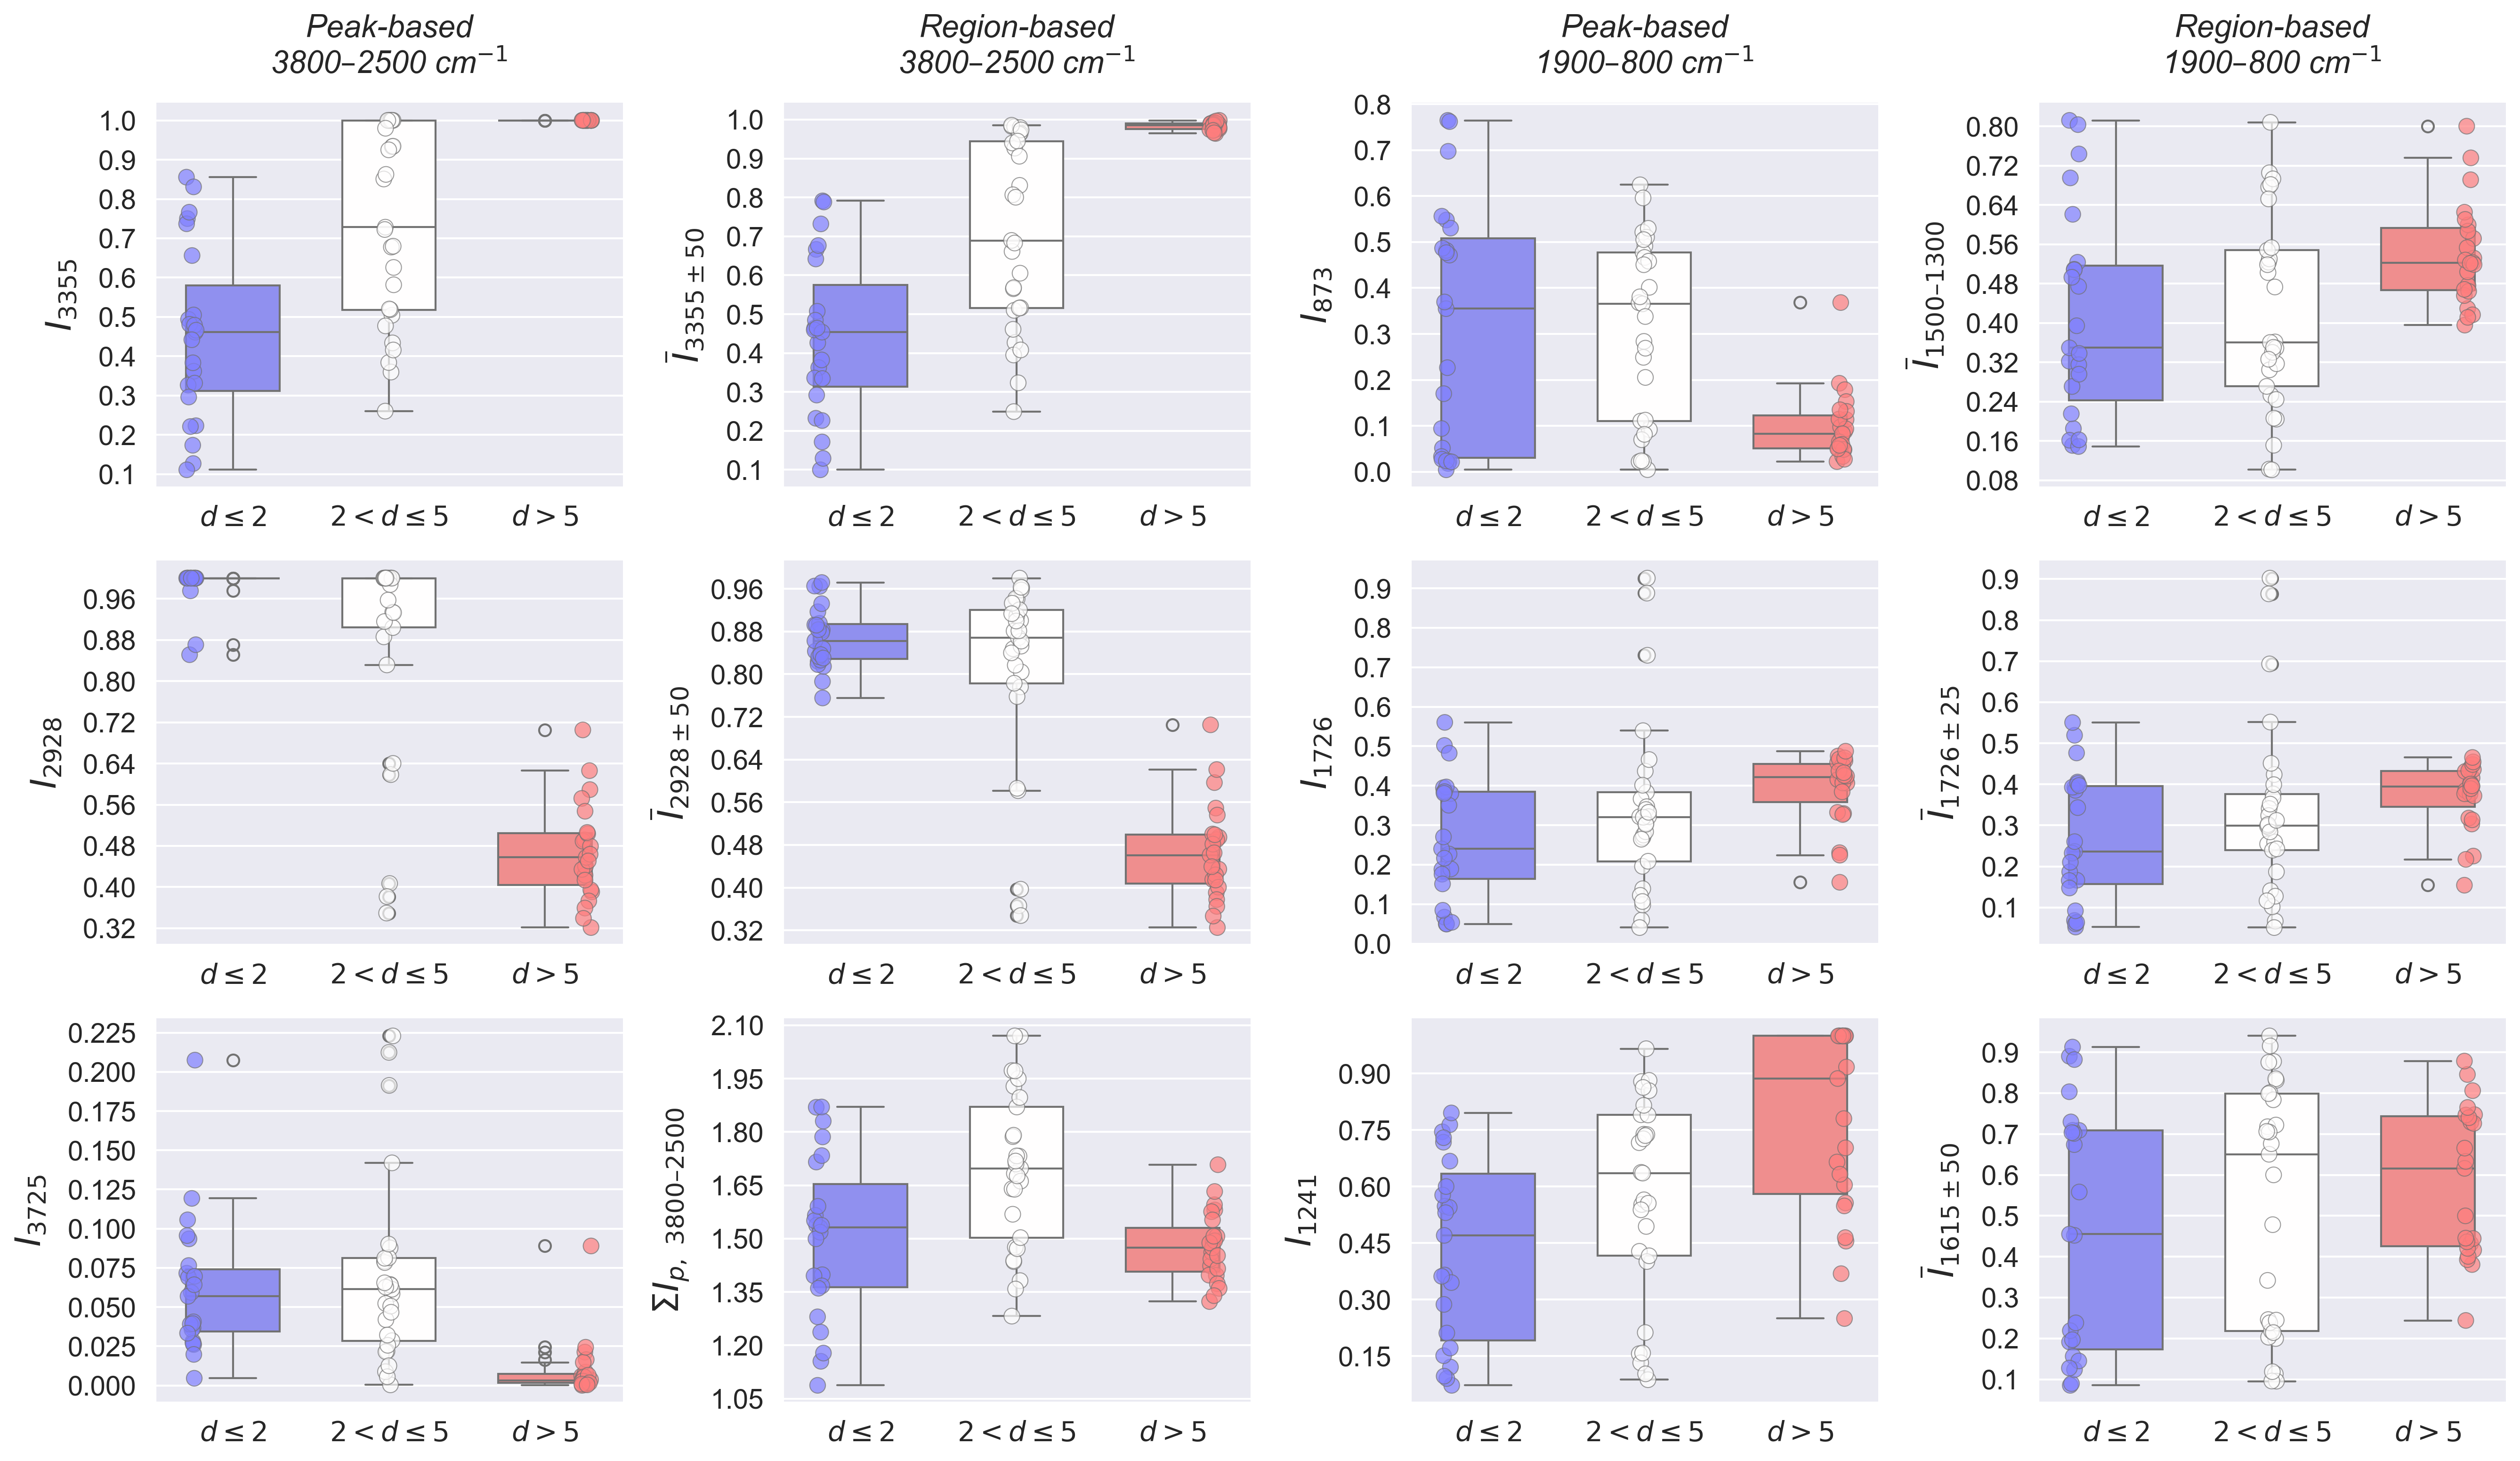

In [27]:
ncols = len(grouped_features)
nrows = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5), dpi=300)
axes = axes.T.flatten()

for col_idx, (feature_type, features) in enumerate(grouped_features.items()):
    for row_idx, feature in enumerate(features):
        ax = axes[col_idx * 3 + row_idx]

        sns.boxplot(
            data=df_vis,
            x='hue',
            y=feature,
            palette='bwr',
            width=PLOT_STYLE['BOX_WIDTH'],
            order=desired_order,
            ax=ax
        )

        sns.stripplot(
            data=df_vis,
            x='hue',
            y=feature,
            order=desired_order,
            palette='bwr',
            dodge=PLOT_STYLE['STRIP_DODGE'],
            alpha=PLOT_STYLE['STRIP_ALPHA'],
            size=PLOT_STYLE['STRIP_SIZE'],
            linewidth=PLOT_STYLE['STRIP_LINEWIDTH'],
            ax=ax,
            legend=False
        )

        if row_idx == 0:
            key = '_'.join(feature_type.split('_')[2:])
            title = f'{TITLE_MAP.get(key, feature_type)}'
            ax.set_title(title, fontsize=PLOT_STYLE['TITLE_FONT_SIZE'], fontstyle=PLOT_STYLE['TITLE_FONTSTYLE'], pad=15)

        ax.set_xlabel('')
        ax.set_ylabel(feature, fontsize=PLOT_STYLE['Y_LABEL_FONT_SIZE'], labelpad=PLOT_STYLE['Y_LABELPAD'])

        ax.tick_params(axis='x', labelsize=PLOT_STYLE['X_TICK_LABEL_FONT_SIZE'])
        ax.tick_params(axis='y', labelsize=PLOT_STYLE['Y_TICK_LABEL_FONT_SIZE'])

        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=PLOT_STYLE['X_NBINS']))

for col_idx, (_, features) in enumerate(grouped_features.items()):
    for r in range(len(features), 3):  # 3 = nrows
        axes[col_idx * 3 + r].axis("off")

plt.tight_layout()

plt.savefig(f'{path_to_save}/boxplot_base_features.png', dpi=1800)
plt.savefig(f'{path_to_save}/boxplot_base_features.svg')

plt.show()

#### Violin plot

In [28]:
PLOT_STYLE = {
    'TITLE_FONT_SIZE': 16,
    'TITLE_FONTSTYLE': 'italic',
    'X_LABEL_FONT_SIZE': 16,
    'Y_LABEL_FONT_SIZE': 18,
    'X_TICK_LABEL_FONT_SIZE': 14,
    'Y_TICK_LABEL_FONT_SIZE': 14,
    'X_LABELPAD': 10,
    'Y_LABELPAD': 10,
    'X_NBINS': 10,
    'VIOLIN_INNER': 'box',  # 'box', 'quartile', 'point', None
    'VIOLIN_CUT': 0,
    'VIOLIN_LINEWIDTH': 1,
    'PALETTE': 'bwr',
}


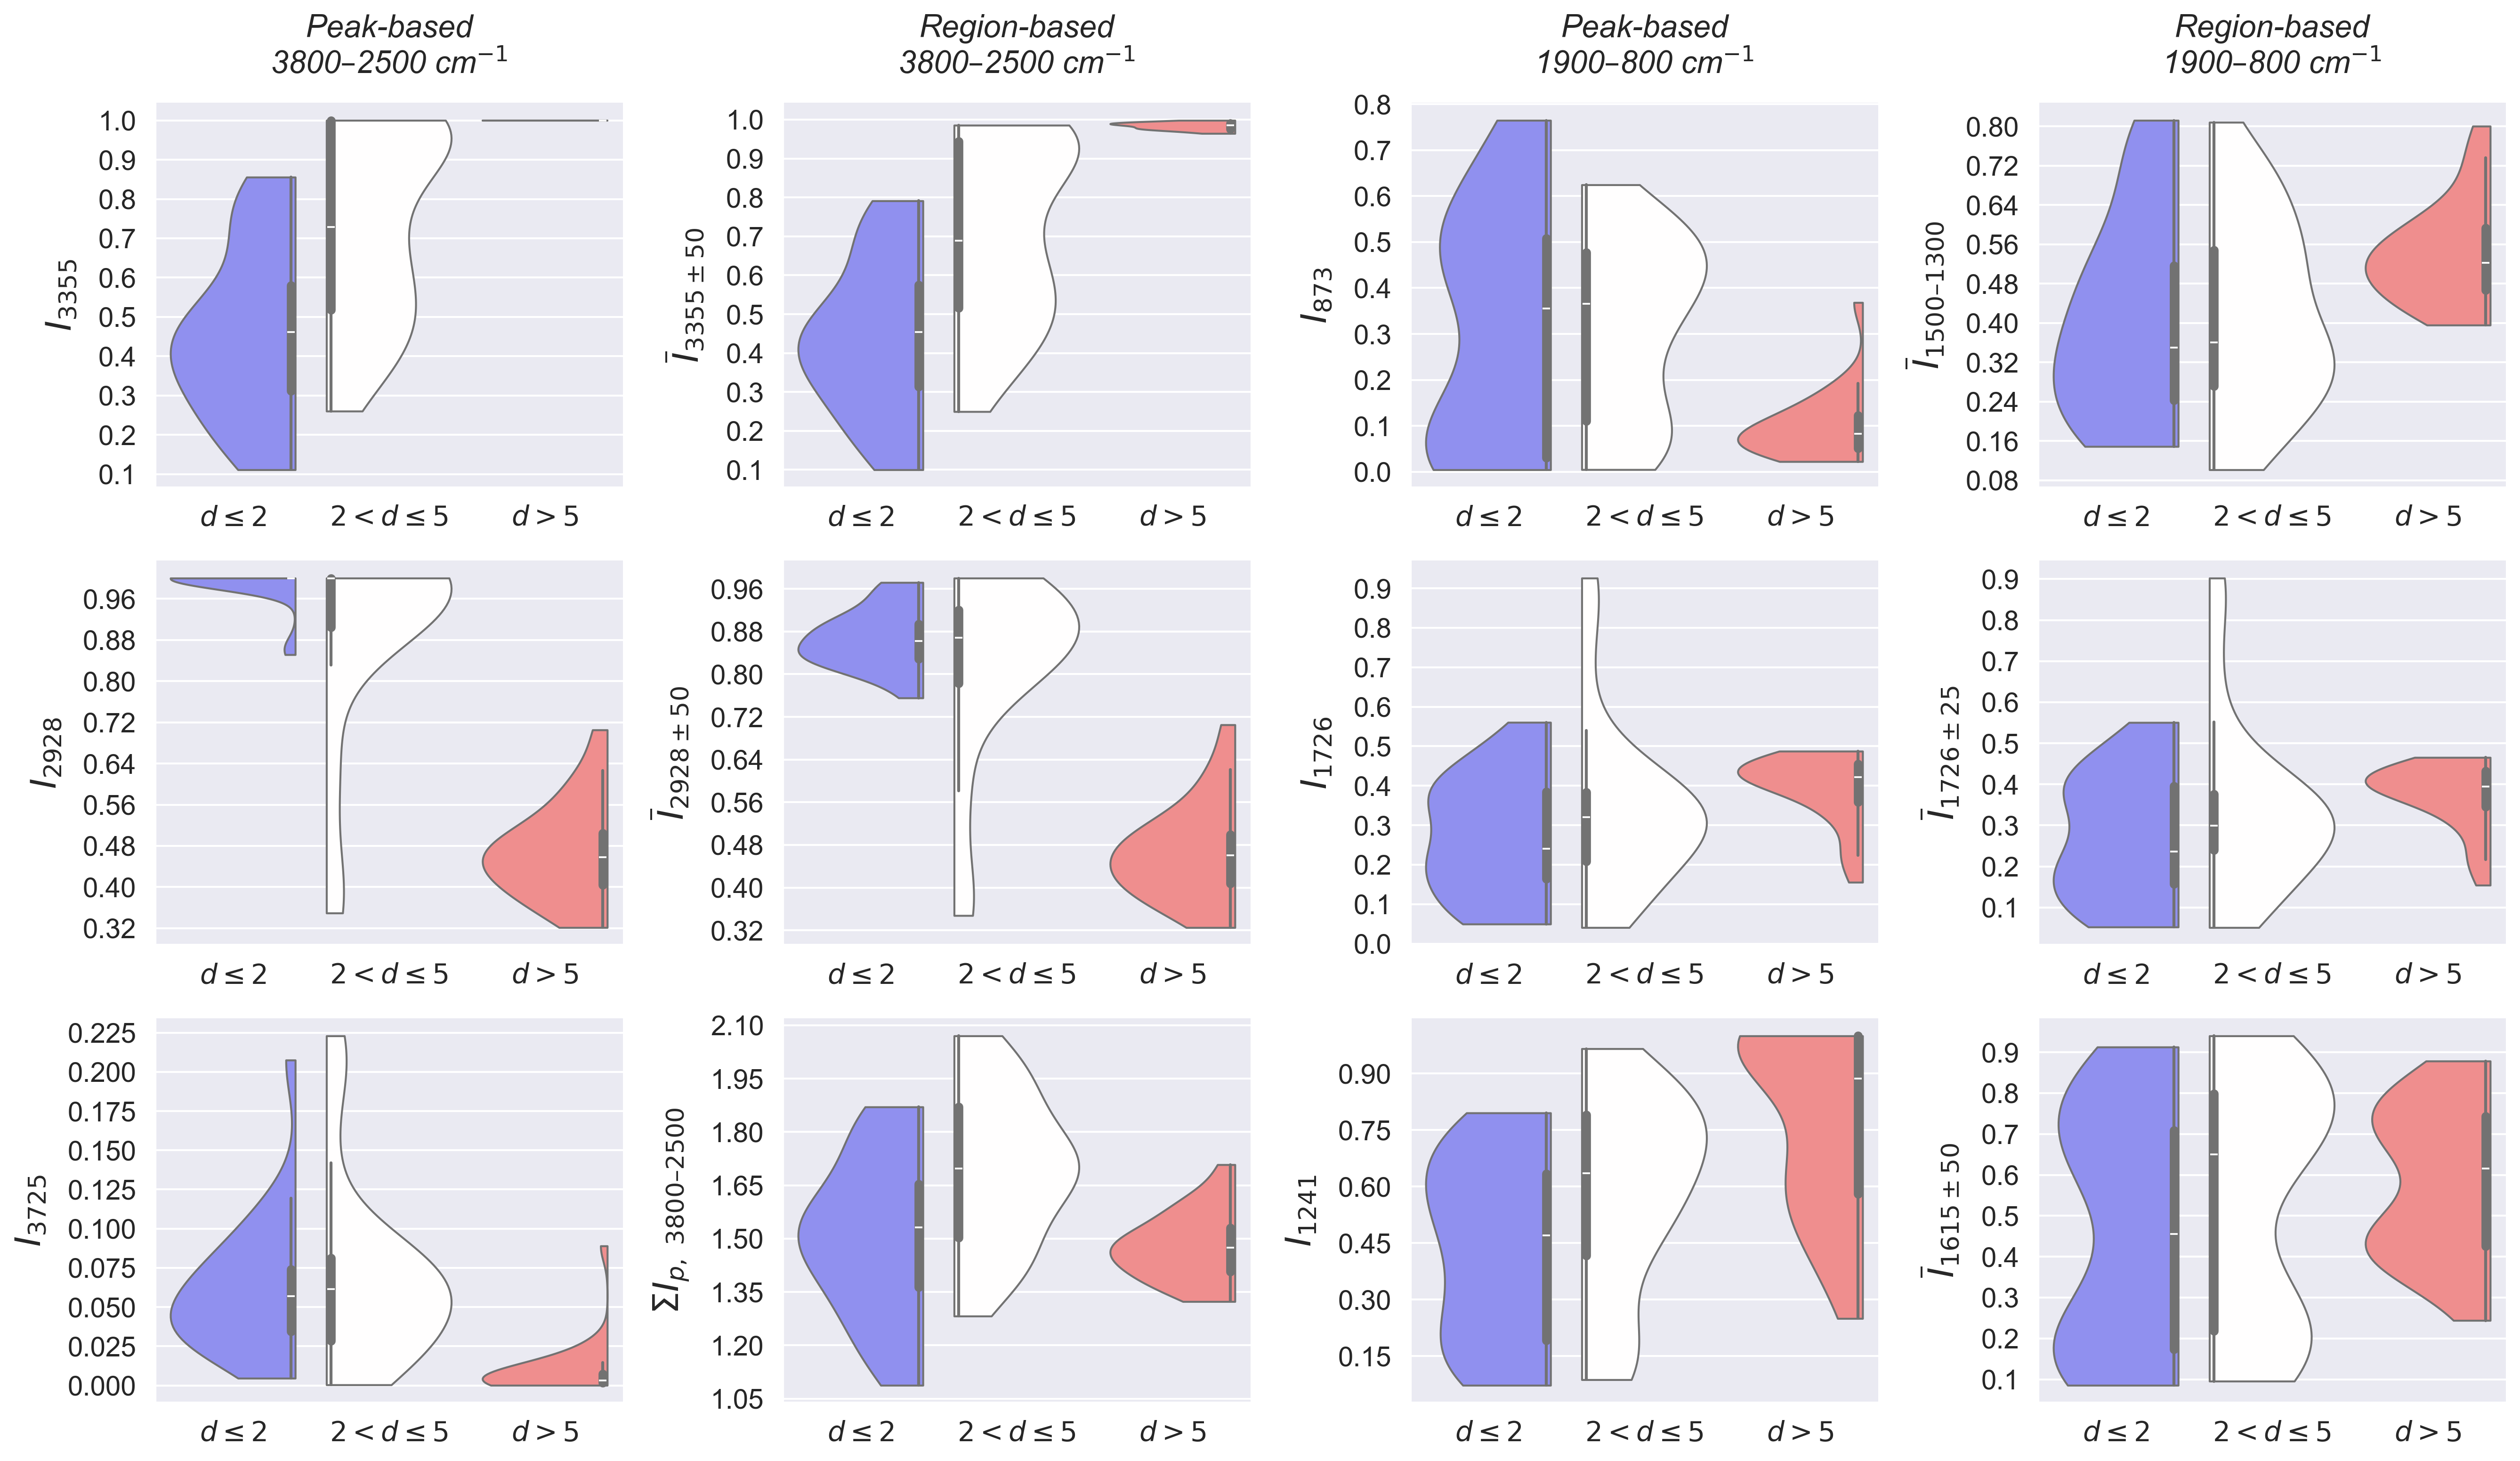

In [29]:
ncols = len(grouped_features)
nrows = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5), dpi=300)
axes = axes.T.flatten()

for col_idx, (feature_type, features) in enumerate(grouped_features.items()):
    for row_idx, feature in enumerate(features):
        ax = axes[col_idx * 3 + row_idx]

        sns.violinplot(
            data=df_vis,
            x='hue',
            y=feature,
            palette=PLOT_STYLE['PALETTE'],
            cut=PLOT_STYLE['VIOLIN_CUT'],
            inner=PLOT_STYLE['VIOLIN_INNER'],
            linewidth=PLOT_STYLE['VIOLIN_LINEWIDTH'],
            split=True,
            order=desired_order,
            ax=ax
        )

        if row_idx == 0:
            key = '_'.join(feature_type.split('_')[2:])
            title = f'{TITLE_MAP.get(key, feature_type)}'
            ax.set_title(title,
                         fontsize=PLOT_STYLE['TITLE_FONT_SIZE'],
                         fontstyle=PLOT_STYLE['TITLE_FONTSTYLE'],
                         pad=15)

        ax.set_xlabel('')
        ax.set_ylabel(
            feature,
            fontsize=PLOT_STYLE['Y_LABEL_FONT_SIZE'],
            labelpad=PLOT_STYLE['Y_LABELPAD']
        )

        ax.tick_params(axis='x', labelsize=PLOT_STYLE['X_TICK_LABEL_FONT_SIZE'])
        ax.tick_params(axis='y', labelsize=PLOT_STYLE['Y_TICK_LABEL_FONT_SIZE'])
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=PLOT_STYLE['X_NBINS']))

for col_idx, (_, features) in enumerate(grouped_features.items()):
    for r in range(len(features), 3):  # 3 = nrows
        axes[col_idx * 3 + r].axis("off")

plt.tight_layout()

plt.savefig(f'{path_to_save}/violinplot_base_features.png', dpi=1800)
plt.savefig(f'{path_to_save}/violinplot_base_features.svg')

plt.show()

### *Engineered* features

#### Ranking features

In [30]:
ranked_data = get_ranked_features_by_mutual_info(
    features_df=features_df,
    target=target,
    features_description=features_description,
    feature_types=engineered_feature_types
)

print(ranked_data.shape)
ranked_data.head(3)

(331, 3)


,Feature,Mutual_Info,Feature_Type
0,$\frac{I_{2928}}{I_{3355}}$,0.517411,engineered_features_peaks_3800_2500
1,$(I_{3355})^{-1}$,0.507807,engineered_features_peaks_3800_2500
2,$\log I_{3355}$,0.502659,engineered_features_peaks_3800_2500


In [31]:
top_n = 3

top_features_df = ranked_data.groupby('Feature_Type').head(top_n)

print(top_features_df.shape)
top_features_df.head(3)

(12, 3)


,Feature,Mutual_Info,Feature_Type
0,$\frac{I_{2928}}{I_{3355}}$,0.517411,engineered_features_peaks_3800_2500
1,$(I_{3355})^{-1}$,0.507807,engineered_features_peaks_3800_2500
2,$\log I_{3355}$,0.502659,engineered_features_peaks_3800_2500


In [32]:
top_features = top_features_df['Feature']

#### Data preparation

In [33]:
df_vis = features_df[top_features].copy()
df_vis['target'] = target
df_vis['hue'] = hue

print(df_vis.shape)
df_vis.head(3)

(75, 14)


,$\frac{I_{2928}}{I_{3355}}$,$(I_{3355})^{-1}$,$\log I_{3355}$,"$\frac{I_{2928}}{\Sigma I_{p,\ 3800\text{–}2500}}$",$\frac{I_{2928}}{\overline{I}_{3800\text{–}2500}}$,$\log \overline{I}_{3355 \pm 50}$,$\frac{I_{873}}{I_{1394}}$,$\frac{I_{873}}{I_{1726}}$,$\frac{I_{873}}{I_{1615}}$,"$\frac{I_{873}}{\Sigma I_{p,\ 1300\text{–}800}}$",$\frac{I_{1241}}{\overline{I}_{873 \pm 50}}$,$\frac{I_{1241}}{\overline{I}_{873 \pm 25}}$,target,hue
division_1_size_bulk,0.491720,1.0,0.0,0.311082,0.934471,-0.017917,0.063384,0.114239,0.048208,0.040697,9.497153,9.571604,2,$d > 5$
division_1_size_5,0.406937,1.0,0.0,0.283488,0.851494,-0.017684,0.133645,0.239657,0.091875,0.081594,4.454221,4.584797,1,$2 < d \leq 5$
division_1_size_3,0.618445,1.0,0.0,0.364289,1.154270,-0.018581,0.158381,0.300882,0.110321,0.081874,3.515446,3.535849,1,$2 < d \leq 5$


In [34]:
feature_type_by_feature = dict(zip(ranked_data['Feature'], ranked_data['Feature_Type']))

grouped_features = defaultdict(list)

for feature in df_vis.columns:
    if feature in ['target', 'hue']:
        continue
    
    feature_type = feature_type_by_feature[feature]
    grouped_features[feature_type].append(feature)

#### Box plot

In [35]:
PLOT_STYLE = {
    'TITLE_FONT_SIZE': 16,
    'TITLE_FONTSTYLE': 'italic',
    'X_LABEL_FONT_SIZE': 16,
    'Y_LABEL_FONT_SIZE': 18,
    'X_TICK_LABEL_FONT_SIZE': 14,
    'Y_TICK_LABEL_FONT_SIZE': 14,
    'X_LABELPAD': 10,
    'Y_LABELPAD': 10,
    'X_NBINS': 10,
    'BOX_WIDTH': 0.6,
    'STRIP_ALPHA': 0.7,
    'STRIP_SIZE': 8,
    'STRIP_LINEWIDTH': 0.5,
    'STRIP_DODGE': True
}

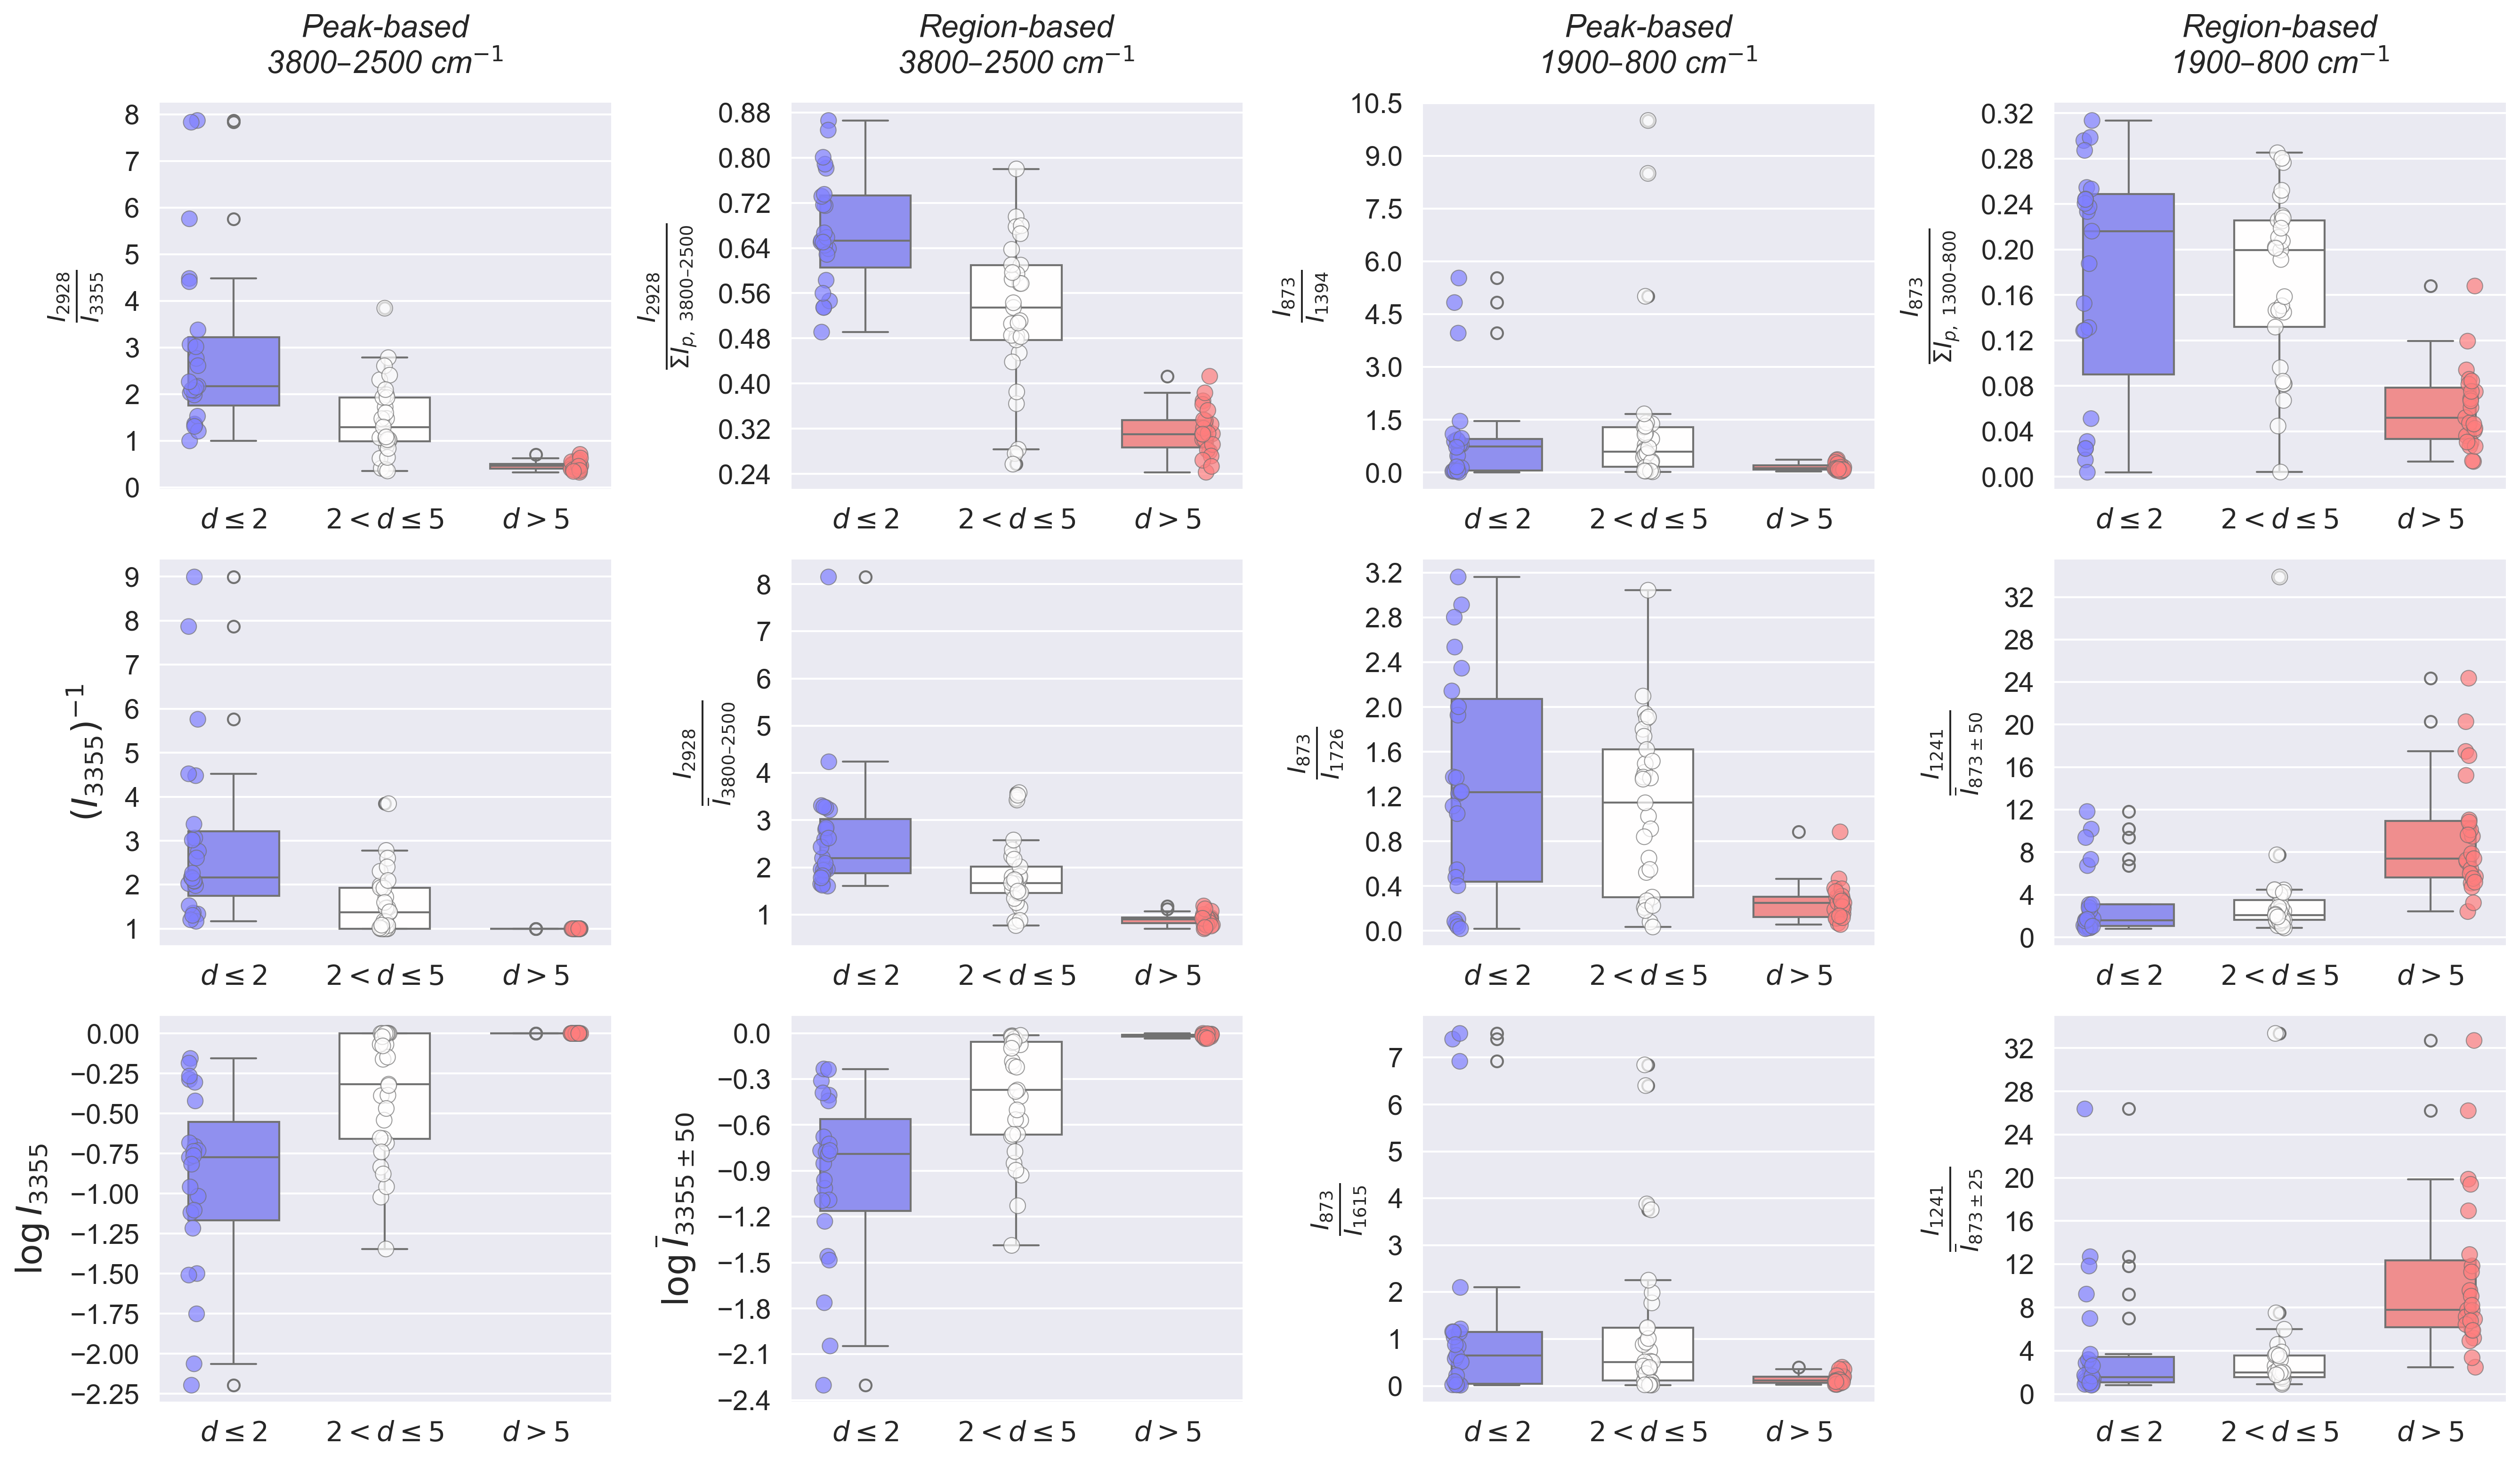

In [36]:
ncols = len(grouped_features)
nrows = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5), dpi=300)
axes = axes.T.flatten()

for col_idx, (feature_type, features) in enumerate(grouped_features.items()):
    for row_idx, feature in enumerate(features):
        ax = axes[col_idx * 3 + row_idx]

        sns.boxplot(
            data=df_vis,
            x='hue',
            y=feature,
            palette='bwr',
            width=PLOT_STYLE['BOX_WIDTH'],
            order=desired_order,
            ax=ax
        )

        sns.stripplot(
            data=df_vis,
            x='hue',
            y=feature,
            order=desired_order,
            palette='bwr',
            dodge=PLOT_STYLE['STRIP_DODGE'],
            alpha=PLOT_STYLE['STRIP_ALPHA'],
            size=PLOT_STYLE['STRIP_SIZE'],
            linewidth=PLOT_STYLE['STRIP_LINEWIDTH'],
            ax=ax,
            legend=False
        )

        if row_idx == 0:
            key = '_'.join(feature_type.split('_')[2:])
            title = f'{TITLE_MAP.get(key, feature_type)}'
            ax.set_title(title, fontsize=PLOT_STYLE['TITLE_FONT_SIZE'], fontstyle=PLOT_STYLE['TITLE_FONTSTYLE'], pad=15)

        ax.set_xlabel('')
        ax.set_ylabel(feature, fontsize=PLOT_STYLE['Y_LABEL_FONT_SIZE'], labelpad=PLOT_STYLE['Y_LABELPAD'])

        ax.tick_params(axis='x', labelsize=PLOT_STYLE['X_TICK_LABEL_FONT_SIZE'])
        ax.tick_params(axis='y', labelsize=PLOT_STYLE['Y_TICK_LABEL_FONT_SIZE'])

        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=PLOT_STYLE['X_NBINS']))

plt.tight_layout()

plt.savefig(f'{path_to_save}/boxplot_engineered_features.png', dpi=1800)
plt.savefig(f'{path_to_save}/boxplot_engineered_features.svg')

plt.show()

#### Violin plot

In [37]:
PLOT_STYLE = {
    'TITLE_FONT_SIZE': 16,
    'TITLE_FONTSTYLE': 'italic',
    'X_LABEL_FONT_SIZE': 16,
    'Y_LABEL_FONT_SIZE': 18,
    'X_TICK_LABEL_FONT_SIZE': 14,
    'Y_TICK_LABEL_FONT_SIZE': 14,
    'X_LABELPAD': 10,
    'Y_LABELPAD': 10,
    'X_NBINS': 10,
    'VIOLIN_INNER': 'box', # 'box', 'quartile', 'point', None
    'VIOLIN_CUT': 0,
    'VIOLIN_LINEWIDTH': 1,
    'PALETTE': 'bwr',
}

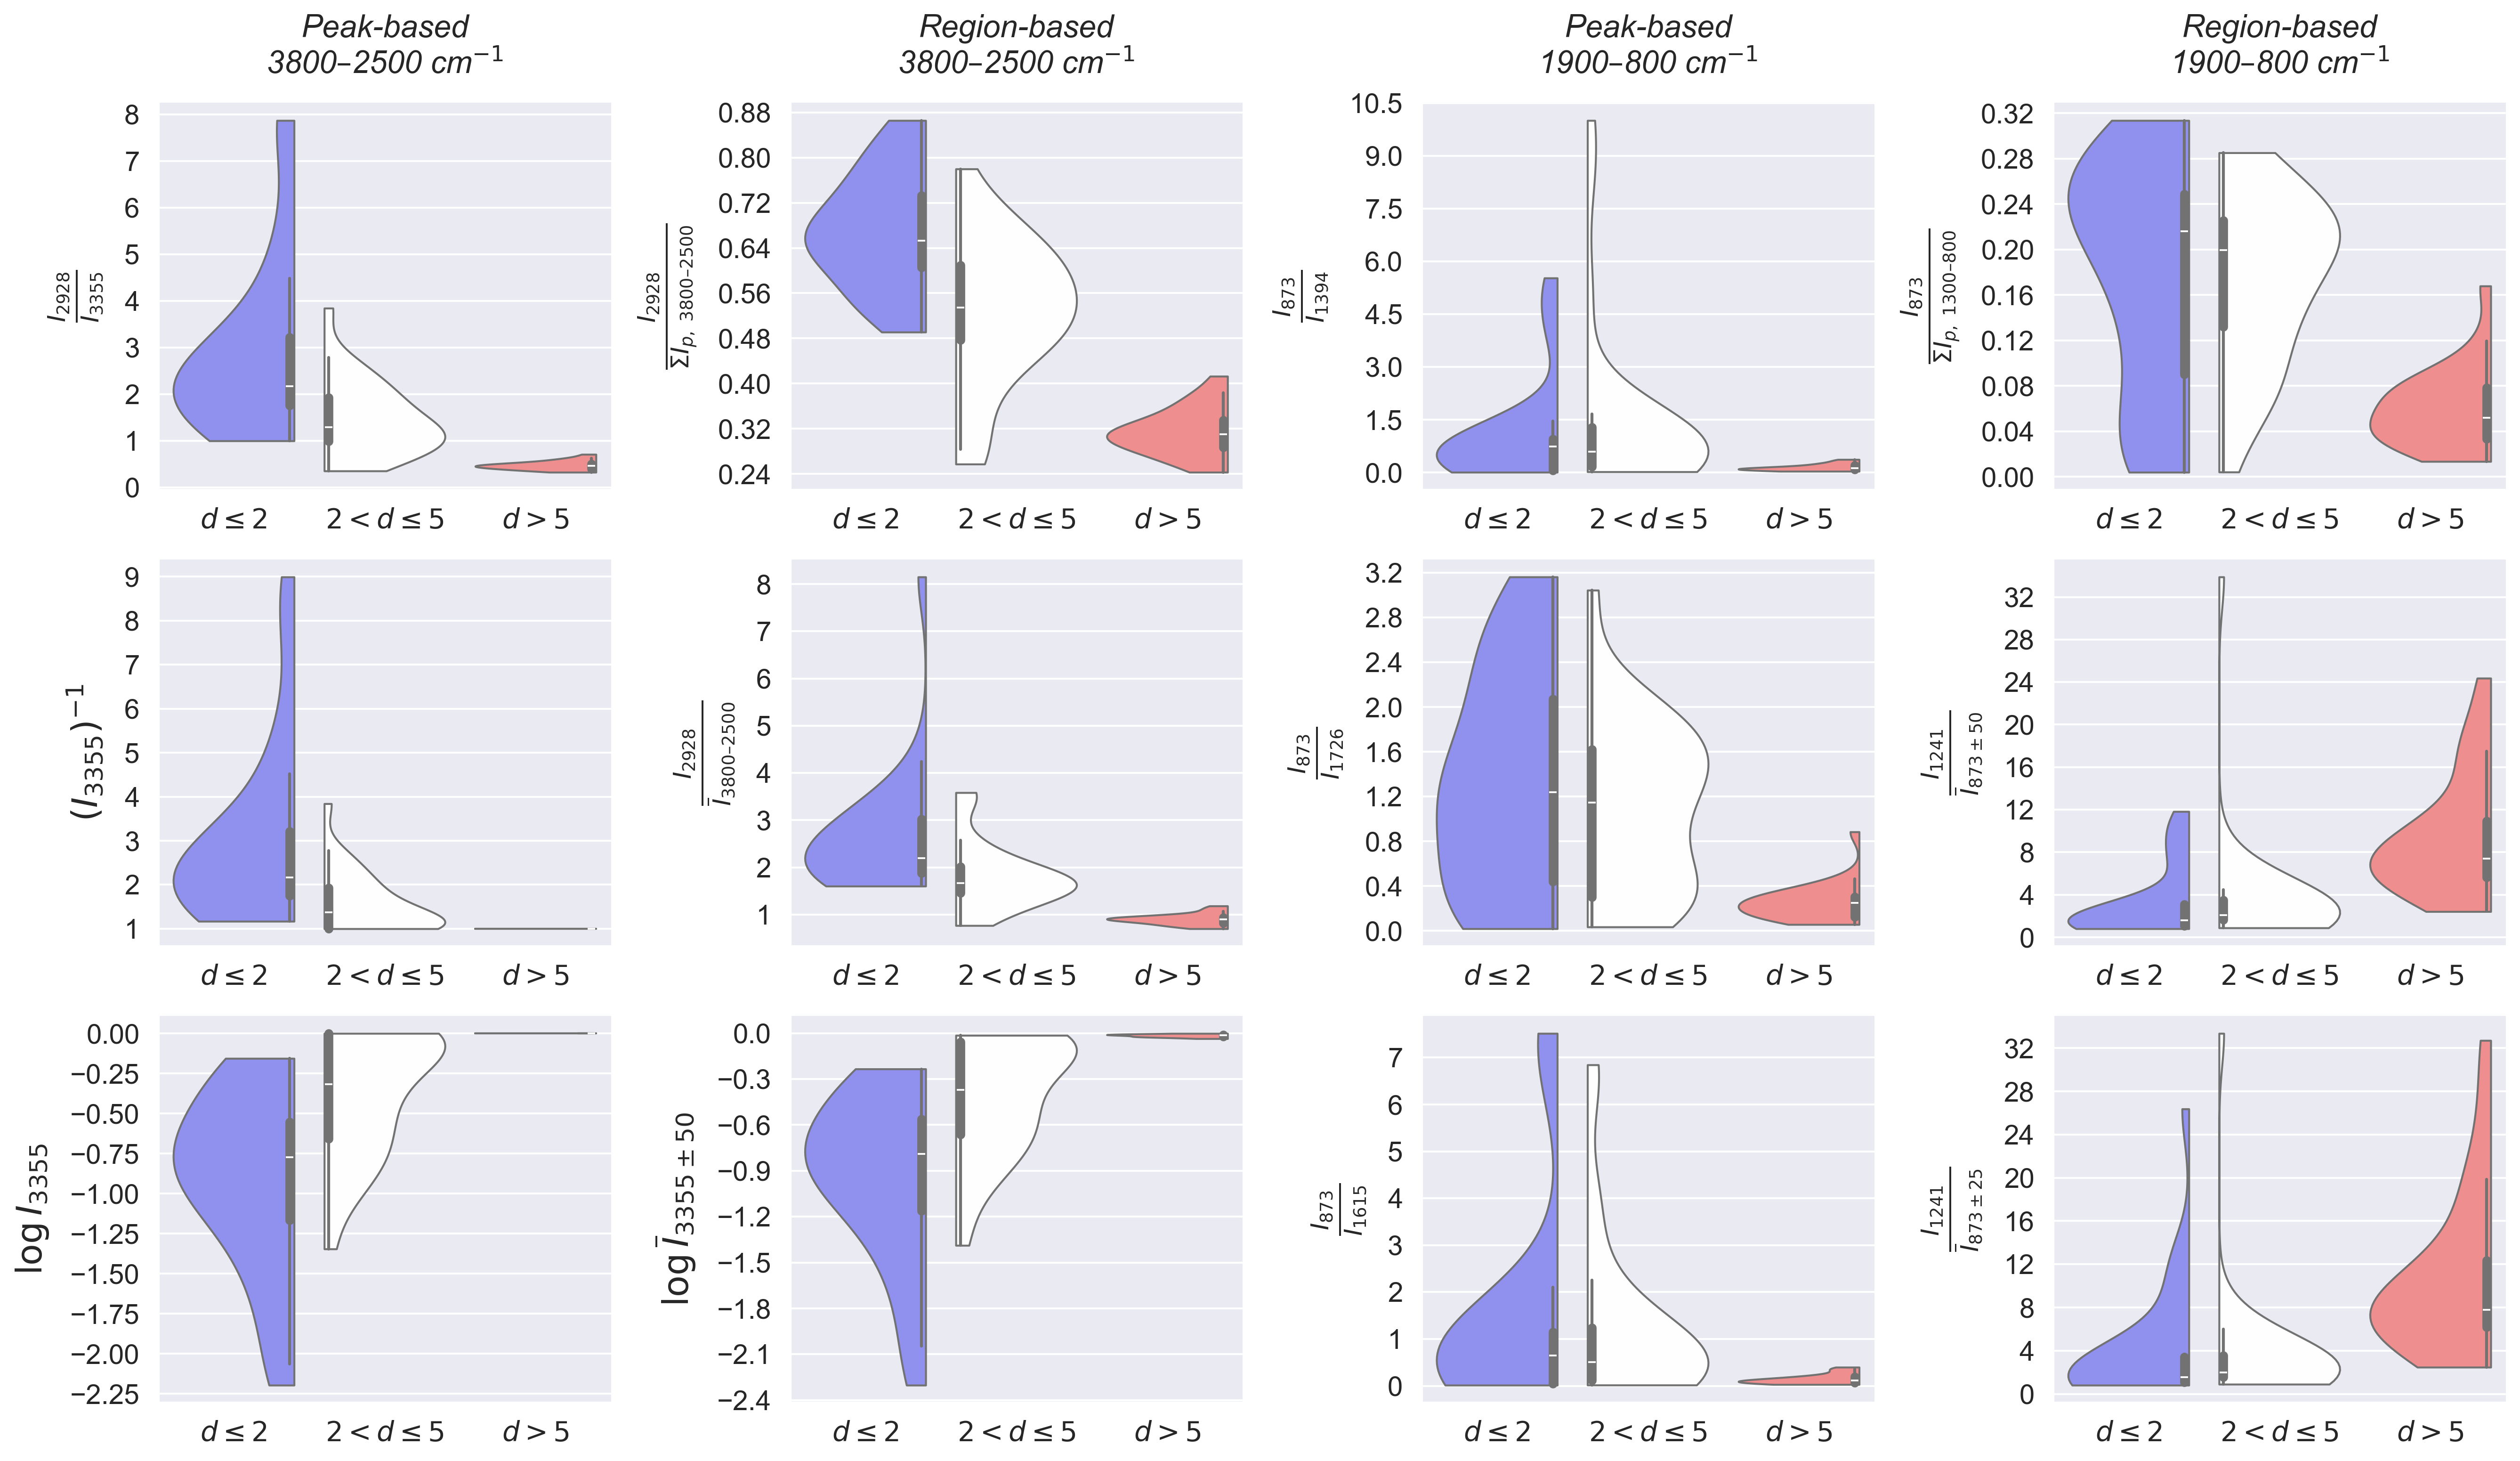

In [38]:
ncols = len(grouped_features)
nrows = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5), dpi=300)
axes = axes.T.flatten()

for col_idx, (feature_type, features) in enumerate(grouped_features.items()):
    for row_idx, feature in enumerate(features):
        ax = axes[col_idx * 3 + row_idx]

        sns.violinplot(
            data=df_vis,
            x='hue',
            y=feature,
            palette=PLOT_STYLE['PALETTE'],
            cut=PLOT_STYLE['VIOLIN_CUT'],
            inner=PLOT_STYLE['VIOLIN_INNER'],
            linewidth=PLOT_STYLE['VIOLIN_LINEWIDTH'],
            split=True,
            order=desired_order,
            ax=ax
        )

        if row_idx == 0:
            key = '_'.join(feature_type.split('_')[2:])
            title = f'{TITLE_MAP.get(key, feature_type)}'
            ax.set_title(title,
                         fontsize=PLOT_STYLE['TITLE_FONT_SIZE'],
                         fontstyle=PLOT_STYLE['TITLE_FONTSTYLE'],
                         pad=15)

        ax.set_xlabel('')
        ax.set_ylabel(
            feature,
            fontsize=PLOT_STYLE['Y_LABEL_FONT_SIZE'],
            labelpad=PLOT_STYLE['Y_LABELPAD']
        )

        ax.tick_params(axis='x', labelsize=PLOT_STYLE['X_TICK_LABEL_FONT_SIZE'])
        ax.tick_params(axis='y', labelsize=PLOT_STYLE['Y_TICK_LABEL_FONT_SIZE'])
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=PLOT_STYLE['X_NBINS']))

plt.tight_layout()

plt.savefig(f'{path_to_save}/violinplot_engineered_features.png', dpi=1800)
plt.savefig(f'{path_to_save}/violinplot_engineered_features.svg')

plt.show()